# Select 16-qubit molecules: (14e, 8o) and similar active spaces

Goal: find molecules where **1–3 UCCSD double excitations** are enough to reach
**chemical accuracy** (≤ ~1.6 mHa vs active-space FCI), at a size of **~16 qubits**.

This extends `F2.ipynb` (F₂ in a (10,6) CAS, 12 qubits) to bigger active spaces.
The candidates are dominated by **one weak σ bond** (σ→σ\* is the only static-correlation
channel), so a single dominant pair double should carry most of the correlation:

| name | molecule | basis | active space | qubits | dominant physics |
|---|---|---|---|---|---|
| `F2` | F₂ | STO-3G | (14, 8) full valence | 16 | σ(2p)→σ\*(2p) |
| `Cl2` | Cl₂ | STO-3G | (14, 8) full valence | 16 | σ(3p)→σ\*(3p), weak bond |
| `ClF` | ClF | STO-3G | (14, 8) full valence | 16 | polar single σ bond |
| `Br2` | Br₂ | STO-3G | (14, 8) full valence | 16 | σ(4p)→σ\*(4p) |
| `H2O2` | H₂O₂ (O–O stretch) | STO-3G | (10, 8) | 16 | σ(O–O)→σ\*(O–O), nv=3 |
| `F2_631G` | F₂ | 6-31G | (14, 10) | 20 | σ→σ\* with competing virtuals |

**How to use**: set `MOLE_NAME` (and optionally `TOP_K`) in the run cell below and execute.
The pipeline mirrors `F2.ipynb`:

1. Full UCCSD in the active space + active-space FCI reference.
2. Reduced ansatz keeping only the **top-k MP2-important doubles** (`build_reduced_topk_doubles_ucc`).
3. Bond-length scan + error vs FCI, with the chemical-accuracy line.
4. MP2 amplitude-concentration screen (how much of Σθ² the top amplitudes carry).
5. A final summary cell that runs **all** molecules at k = 1, 2, 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tencirchem import UCCSD, M

plt.style.use("seaborn-v0_8-whitegrid")

CHEM_ACC_MHA = 1.6  # ~1 kcal/mol = 1.594 mHa

/Users/zacharyhe/cross_chips_sim/.venv_h4_tencirchem/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Molecule registry: run any entry by name, e.g. run_mole_scan("Cl2", top_k=1).
# Each entry provides:
#   builder(d)     -> tencirchem M molecule at scan coordinate d (angstrom)
#   active_space   -> (n_active_electrons, n_active_spatial_orbitals)
#   d_grid         -> bond-length scan grid
#   d_eq           -> approximate equilibrium distance (used by the convergence cell)


def make_diatomic(sym1, sym2, basis="sto-3g"):
    def build(d):
        return M(
            atom=[[sym1, 0, 0, -d / 2], [sym2, 0, 0, d / 2]],
            basis=basis,
            unit="Angstrom",
        )

    return build


def make_h2o2(d_oo, r_oh=0.95, angle_ooh_deg=99.9, dihedral_deg=113.7):
    """H2O2 with the O-O distance as scan coordinate; OH bonds/angles fixed."""
    th = np.deg2rad(angle_ooh_deg)
    ph = np.deg2rad(dihedral_deg)
    o1 = np.array([0.0, 0.0, 0.0])
    o2 = np.array([0.0, 0.0, d_oo])
    h1 = o1 + r_oh * np.array([np.sin(th), 0.0, np.cos(th)])
    h2 = o2 + r_oh * np.array([np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), -np.cos(th)])
    atoms = [
        ["O", *o1.tolist()],
        ["O", *o2.tolist()],
        ["H", *h1.tolist()],
        ["H", *h2.tolist()],
    ]
    return M(atom=atoms, basis="sto-3g", unit="Angstrom")


def grid(start, stop, step=0.2):
    return np.round(np.arange(start, stop + 1e-9, step), 2)


MOLES = {
    # Full-valence (14,8): freeze the 1s cores of F2 (vs (10,6) in F2.ipynb).
    "F2": dict(
        builder=make_diatomic("F", "F"),
        active_space=(14, 8),
        n_qubits=16,
        d_grid=grid(1.0, 3.0),
        d_eq=1.41,
        bond="F-F",
        note="full valence 2s/2p; single sigma(2p)->sigma*(2p) channel",
    ),
    # Full-valence 3s/3p: freeze 1s,2s,2p cores (10 MOs). Weakest bond -> most dominant double.
    "Cl2": dict(
        builder=make_diatomic("Cl", "Cl"),
        active_space=(14, 8),
        n_qubits=16,
        d_grid=grid(1.6, 3.6),
        d_eq=1.99,
        bond="Cl-Cl",
        note="full valence 3s/3p; weak bond, large sigma->sigma* MP2 amplitude",
    ),
    # Heteronuclear interhalogen: same (14,8) valence structure without D-inf-h symmetry.
    "ClF": dict(
        builder=make_diatomic("Cl", "F"),
        active_space=(14, 8),
        n_qubits=16,
        d_grid=grid(1.2, 3.2),
        d_eq=1.63,
        bond="Cl-F",
        note="polar single sigma bond; freeze Cl(1s2s2p)+F(1s)",
    ),
    # Heavy homologue: freeze 1s..3d cores (28 MOs), active 4s/4p valence.
    "Br2": dict(
        builder=make_diatomic("Br", "Br"),
        active_space=(14, 8),
        n_qubits=16,
        d_grid=grid(2.0, 4.0),
        d_eq=2.28,
        bond="Br-Br",
        note="full valence 4s/4p; sigma(4p)->sigma*(4p)",
    ),
    # Polyatomic with a single weak O-O bond; nv=3 makes the truncation test stronger.
    "H2O2": dict(
        builder=make_h2o2,
        active_space=(10, 8),
        n_qubits=16,
        d_grid=grid(1.0, 3.0),
        d_eq=1.48,
        bond="O-O",
        note="O-O stretch; sigma(OO)->sigma*(OO) among 3 active virtuals",
    ),
    # Bigger basis -> extra competing virtuals (20 qubits): stronger dominance test.
    "F2_631G": dict(
        builder=make_diatomic("F", "F", basis="6-31g"),
        active_space=(14, 10),
        n_qubits=20,
        d_grid=grid(1.0, 3.0),
        d_eq=1.41,
        bond="F-F",
        note="6-31G, (14,10); sigma* competes with extra virtuals",
    ),
}

for _name, _cfg in MOLES.items():
    ne, no = _cfg["active_space"]
    print(
        f"{_name:8s} active_space=({ne},{no}) -> {_cfg['n_qubits']} qubits | "
        f"scan {_cfg['bond']} {_cfg['d_grid'][0]:.1f}..{_cfg['d_grid'][-1]:.1f} A | {_cfg['note']}"
    )

F2       active_space=(14,8) -> 16 qubits | scan F-F 1.0..3.0 A | full valence 2s/2p; single sigma(2p)->sigma*(2p) channel
Cl2      active_space=(14,8) -> 16 qubits | scan Cl-Cl 1.6..3.6 A | full valence 3s/3p; weak bond, large sigma->sigma* MP2 amplitude
ClF      active_space=(14,8) -> 16 qubits | scan Cl-F 1.2..3.2 A | polar single sigma bond; freeze Cl(1s2s2p)+F(1s)
Br2      active_space=(14,8) -> 16 qubits | scan Br-Br 2.0..4.0 A | full valence 4s/4p; sigma(4p)->sigma*(4p)
H2O2     active_space=(10,8) -> 16 qubits | scan O-O 1.0..3.0 A | O-O stretch; sigma(OO)->sigma*(OO) among 3 active virtuals
F2_631G  active_space=(14,10) -> 20 qubits | scan F-F 1.0..3.0 A | 6-31G, (14,10); sigma* competes with extra virtuals


In [3]:
def build_reduced_topk_doubles_ucc(mol, active_space, k):
    """Build a UCCSD instance that keeps top-k MP2-important double parameters only.

    Same construction as in F2.ipynb.
    """
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )

    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_ops = {}
    for op, pid in zip(all_ops, all_param_ids):
        pid_to_ops.setdefault(pid, []).append(op)

    # Keep only pure-double parameters.
    double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    if len(double_pids) == 0:
        raise ValueError("No double-excitation parameters found.")

    pid_to_guess = {pid: all_init_guess[pid] for pid in double_pids}
    sorted_pids = sorted(double_pids, key=lambda pid: abs(pid_to_guess[pid]), reverse=True)
    selected_pids = sorted_pids[:k]

    selected_pids_set = set(selected_pids)
    selected_ex_ops = []
    selected_param_ids = []
    selected_pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_pids_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            selected_pid_to_ops[pid].append(op)

    pid_remap = {old_pid: new_pid for new_pid, old_pid in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[pid] for pid in selected_param_ids]
    selected_init_guess = [pid_to_guess[pid] for pid in selected_pids]

    reduced = UCCSD(
        mol,
        active_space=active_space,
        init_method="zeros",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = selected_init_guess

    def op_to_string(op):
        p, q, r, s = op
        return f"a{p}dag a{q}dag a{r} a{s}"

    selected_rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        linked_ops = selected_pid_to_ops[pid]
        selected_rows.append(
            {
                "rank": rank,
                "param_id_index": pid,
                "factor_type": "double",
                "mp2_init_theta": pid_to_guess[pid],
                "abs_mp2_init_theta": abs(pid_to_guess[pid]),
                "n_ex_ops_linked": len(linked_ops),
                "op_terms": " | ".join(op_to_string(op) for op in linked_ops),
            }
        )

    selected_meta_df = pd.DataFrame(selected_rows)
    return reduced, selected_pids, selected_ex_ops, selected_meta_df


def mp2_doubles_concentration(mol, active_space, top_n=3):
    """Fraction of sum(theta^2) carried by the top-n MP2 double amplitudes.

    Cheap classical screen: if top-1..3 carry ~all of sum(theta^2), the reduced
    ansatz will almost certainly reach chemical accuracy.
    """
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    pid_to_ops = {}
    for op, pid in zip(probe.ex_ops, probe.param_ids):
        pid_to_ops.setdefault(pid, []).append(op)
    thetas = np.array(
        [probe.init_guess[pid] for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    )
    w = np.sort(thetas**2)[::-1]
    frac = np.cumsum(w) / w.sum()
    out = {"n_doubles_total": len(w)}
    for n in range(1, top_n + 1):
        out[f"top{n}_theta2_frac"] = float(frac[min(n, len(w)) - 1])
    return out


def run_mole_scan(mole_name, top_k=1, d_grid=None, verbose=True):
    """Scan bond length for one registry molecule.

    At each geometry: full UCCSD in the active space (+ FCI reference) and the
    reduced top-k-doubles ansatz, exactly as in F2.ipynb.
    """
    cfg = MOLES[mole_name]
    active_space = cfg["active_space"]
    if d_grid is None:
        d_grid = cfg["d_grid"]

    rows = []
    for d in d_grid:
        mol = cfg["builder"](d)

        ucc_as = UCCSD(
            mol,
            active_space=active_space,
            init_method="mp2",
            pick_ex2=True,
            sort_ex2=True,
            run_fci=True,
        )
        e_as = ucc_as.kernel()
        e_fci = ucc_as.e_fci

        reduced_ucc, selected_pids, selected_ex_ops, _ = build_reduced_topk_doubles_ucc(
            mol, active_space, top_k
        )
        e_topk = reduced_ucc.kernel()

        conc = mp2_doubles_concentration(mol, active_space)

        row = {
            "d_angstrom": d,
            "E_HF_Ha": ucc_as.e_hf,
            "E_UCCSD_Ha": e_as,
            "E_topk_doubles_Ha": e_topk,
            "E_FCI_Ha": e_fci,
            "uccsd_minus_fci_mHa": (e_as - e_fci) * 1000,
            "topk_minus_fci_mHa": (e_topk - e_fci) * 1000,
            "topk_within_chem_acc": bool(abs(e_topk - e_fci) * 1000 <= CHEM_ACC_MHA),
            "n_ex_ops_kept": len(selected_ex_ops),
            "selected_param_ids": str(selected_pids),
        }
        row.update(conc)
        rows.append(row)

        if verbose:
            print(
                f"[{mole_name}] d={d:.2f} A  "
                f"E_top{top_k}-E_FCI = {(e_topk - e_fci) * 1000:+8.3f} mHa  "
                f"(UCCSD-FCI = {(e_as - e_fci) * 1000:+7.3f} mHa, "
                f"top1 theta^2 frac = {conc['top1_theta2_frac']:.3f})"
            )

    return pd.DataFrame(rows).sort_values("d_angstrom").reset_index(drop=True)

In [4]:
# =========================================================
# Choose the molecule to run here (any key of MOLES above).
# =========================================================
MOLE_NAME = "Cl2"
TOP_K = 1
# =========================================================

cfg = MOLES[MOLE_NAME]
print(
    f"Running {MOLE_NAME}: active_space={cfg['active_space']} -> {cfg['n_qubits']} qubits, "
    f"top_k={TOP_K}, scan {cfg['bond']} = {cfg['d_grid'][0]:.2f}..{cfg['d_grid'][-1]:.2f} A"
)

scan_df = run_mole_scan(MOLE_NAME, top_k=TOP_K)

# Detailed top-k doubles chosen near equilibrium.
report_mol = cfg["builder"](cfg["d_eq"])
_, selected_pids, _, selected_meta_df = build_reduced_topk_doubles_ucc(
    report_mol, cfg["active_space"], TOP_K
)
print(f"\nTop-{TOP_K} doubles (ranked by |MP2 theta|) at d = {cfg['d_eq']:.2f} A:")
display(selected_meta_df)
display(scan_df)

Running Cl2: active_space=(14, 8) -> 16 qubits, top_k=1, scan Cl-Cl = 1.60..3.60 A
[Cl2] d=1.60 A  E_top1-E_FCI =   +5.172 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.621)


[Cl2] d=1.80 A  E_top1-E_FCI =   +5.615 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.709)
[Cl2] d=2.00 A  E_top1-E_FCI =   +5.665 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.788)


[Cl2] d=2.20 A  E_top1-E_FCI =   +5.302 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.849)
[Cl2] d=2.40 A  E_top1-E_FCI =   +4.623 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.894)


[Cl2] d=2.60 A  E_top1-E_FCI =   +3.769 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.925)


[Cl2] d=2.80 A  E_top1-E_FCI =   +2.901 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.946)


[Cl2] d=3.00 A  E_top1-E_FCI =   +2.153 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.961)
[Cl2] d=3.20 A  E_top1-E_FCI =   +1.588 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.971)


[Cl2] d=3.40 A  E_top1-E_FCI =   +1.199 mHa  (UCCSD-FCI =  +0.000 mHa, top1 theta^2 frac = 0.978)


[Cl2] d=3.60 A  E_top1-E_FCI =   +1.274 mHa  (UCCSD-FCI =  +0.318 mHa, top1 theta^2 frac = 0.983)

Top-1 doubles (ranked by |MP2 theta|) at d = 1.99 A:


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,12,double,-0.100642,0.100642,1,a7dag a15dag a10 a2


,d_angstrom,E_HF_Ha,E_UCCSD_Ha,E_topk_doubles_Ha,E_FCI_Ha,uccsd_minus_fci_mHa,topk_minus_fci_mHa,topk_within_chem_acc,n_ex_ops_kept,selected_param_ids,n_doubles_total,top1_theta2_frac,top2_theta2_frac,top3_theta2_frac
0,1.6,-908.863990,-908.877713,-908.872541,-908.877713,7.617018e-09,5.171529,False,1,[21],28,0.620602,0.726454,0.799537
1,1.8,-909.056770,-909.076320,-909.070705,-909.076320,2.205525e-08,5.615195,False,1,[21],28,0.708633,0.794571,0.844848
2,2.0,-909.112719,-909.141050,-909.135385,-909.141050,3.649347e-08,5.665021,False,1,[12],28,0.787696,0.853013,0.888392
3,2.2,-909.106315,-909.147269,-909.141967,-909.147269,3.626610e-08,5.301806,False,1,[21],28,0.849291,0.896573,0.922615
4,2.4,-909.074298,-909.132450,-909.127827,-909.132450,2.535216e-08,4.623030,False,1,[21],28,0.893838,0.926984,0.945969
5,2.6,-909.034836,-909.114648,-909.110879,-909.114648,1.546141e-08,3.769456,False,1,[34],28,0.924970,0.947820,0.961642
6,2.8,-908.996507,-909.100936,-909.098035,-909.100936,1.148237e-08,2.901185,False,1,[34],28,0.946388,0.962103,0.972203
7,3.0,-908.962928,-909.092418,-909.090264,-909.092418,4.774847e-09,2.153427,False,1,[34],28,0.961019,0.971942,0.979397
8,3.2,-908.935234,-909.087834,-909.086247,-909.087834,2.842171e-09,1.587558,True,1,[34],28,0.970997,0.978754,0.984352
9,3.4,-908.913335,-909.085642,-909.084443,-909.085642,1.591616e-09,1.199121,True,1,[34],28,0.977822,0.983497,0.987800


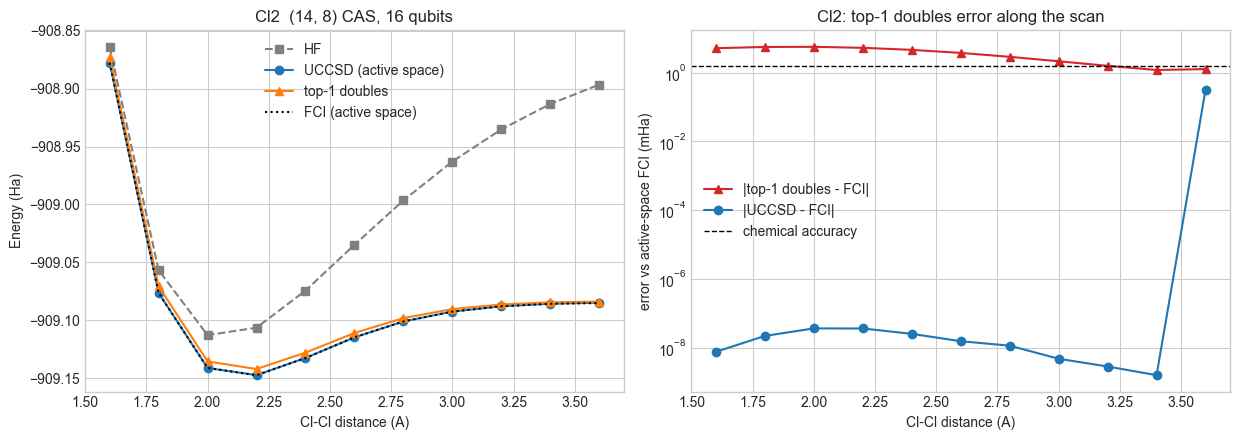

Cl2, top_k=1: 3/11 geometries within chemical accuracy; max |E_topk - E_FCI| = 5.665 mHa


In [5]:
# Potential-energy curves and error vs FCI for the selected molecule.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax1.plot(scan_df["d_angstrom"], scan_df["E_HF_Ha"], "s--", color="gray", label="HF")
ax1.plot(scan_df["d_angstrom"], scan_df["E_UCCSD_Ha"], "o-", label="UCCSD (active space)")
ax1.plot(
    scan_df["d_angstrom"],
    scan_df["E_topk_doubles_Ha"],
    "^-",
    label=f"top-{TOP_K} doubles",
)
ax1.plot(scan_df["d_angstrom"], scan_df["E_FCI_Ha"], "k:", label="FCI (active space)")
ax1.set_xlabel(f"{cfg['bond']} distance (A)")
ax1.set_ylabel("Energy (Ha)")
ax1.set_title(f"{MOLE_NAME}  {cfg['active_space']} CAS, {cfg['n_qubits']} qubits")
ax1.legend()

ax2.plot(
    scan_df["d_angstrom"],
    scan_df["topk_minus_fci_mHa"].abs(),
    "^-",
    color="tab:red",
    label=f"|top-{TOP_K} doubles - FCI|",
)
ax2.plot(
    scan_df["d_angstrom"],
    scan_df["uccsd_minus_fci_mHa"].abs(),
    "o-",
    color="tab:blue",
    label="|UCCSD - FCI|",
)
ax2.axhline(CHEM_ACC_MHA, color="black", linestyle="--", linewidth=1.0, label="chemical accuracy")
ax2.set_xlabel(f"{cfg['bond']} distance (A)")
ax2.set_ylabel("error vs active-space FCI (mHa)")
ax2.set_yscale("log")
ax2.set_title(f"{MOLE_NAME}: top-{TOP_K} doubles error along the scan")
ax2.legend()

plt.tight_layout()
plt.show()

n_ok = int(scan_df["topk_within_chem_acc"].sum())
print(
    f"{MOLE_NAME}, top_k={TOP_K}: {n_ok}/{len(scan_df)} geometries within chemical accuracy; "
    f"max |E_topk - E_FCI| = {scan_df['topk_minus_fci_mHa'].abs().max():.3f} mHa"
)

Cl2 convergence at d = 1.99 A (total doubles = 28, showing k = 1..12)
HF  = -909.11182388 Ha
FCI = -909.13963193 Ha   full UCCSD = -909.13963193 Ha


,n_doubles_kept,n_ex_ops,E_reduced_Ha,error_vs_FCI_mHa
0,1,1,-909.133959,5.672819
1,2,2,-909.135361,4.270552
2,3,3,-909.136260,3.372084
3,4,4,-909.136869,2.763333
4,5,5,-909.137437,2.194465
5,6,6,-909.137509,2.122630
6,7,7,-909.137580,2.051987
7,8,9,-909.139369,0.262818
8,9,11,-909.139369,0.262818
9,10,13,-909.139369,0.262818


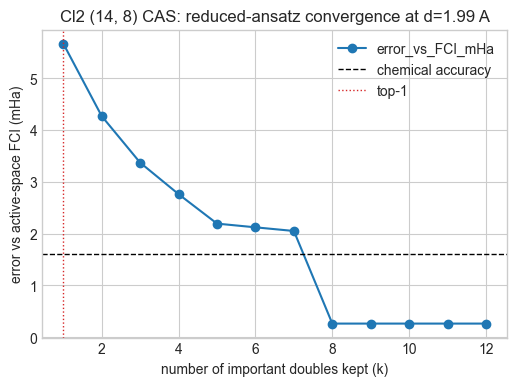

In [6]:
# Convergence check at equilibrium (same as F2.ipynb sanity cell):
# error vs FCI should decrease smoothly as more important doubles are kept.
conv_d = cfg["d_eq"]
conv_mol = cfg["builder"](conv_d)

conv_ref = UCCSD(
    conv_mol,
    active_space=cfg["active_space"],
    init_method="mp2",
    pick_ex2=True,
    sort_ex2=True,
    run_fci=True,
)
e_full_conv = conv_ref.kernel()
e_fci_conv = conv_ref.e_fci

n_doubles_total = mp2_doubles_concentration(conv_mol, cfg["active_space"])["n_doubles_total"]
k_max = min(n_doubles_total, 12)

conv_rows = []
for k in range(1, k_max + 1):
    red_k, _, ex_ops_k, _ = build_reduced_topk_doubles_ucc(conv_mol, cfg["active_space"], k)
    e_k = red_k.kernel()
    conv_rows.append(
        {
            "n_doubles_kept": k,
            "n_ex_ops": len(ex_ops_k),
            "E_reduced_Ha": e_k,
            "error_vs_FCI_mHa": (e_k - e_fci_conv) * 1000,
        }
    )

conv_df = pd.DataFrame(conv_rows)
print(
    f"{MOLE_NAME} convergence at d = {conv_d:.2f} A "
    f"(total doubles = {n_doubles_total}, showing k = 1..{k_max})"
)
print(f"HF  = {conv_ref.e_hf:.8f} Ha")
print(f"FCI = {e_fci_conv:.8f} Ha   full UCCSD = {e_full_conv:.8f} Ha")
display(conv_df)

ax = conv_df.plot(
    x="n_doubles_kept",
    y="error_vs_FCI_mHa",
    marker="o",
    legend=False,
    figsize=(6, 4),
)
ax.axhline(CHEM_ACC_MHA, color="black", linestyle="--", linewidth=1.0, label="chemical accuracy")
ax.axvline(TOP_K, color="tab:red", linestyle=":", linewidth=1.0, label=f"top-{TOP_K}")
ax.set_xlabel("number of important doubles kept (k)")
ax.set_ylabel("error vs active-space FCI (mHa)")
ax.set_title(f"{MOLE_NAME} {cfg['active_space']} CAS: reduced-ansatz convergence at d={conv_d:.2f} A")
ax.legend()
plt.show()

In [7]:
# =========================================================================
# Summary over ALL registry molecules: how does each behave at k = 1, 2, 3?
# Uses a coarser grid (every other scan point) to keep the runtime modest.
# =========================================================================
K_LIST = (1, 2, 3)

summary_rows = []
for name, mcfg in MOLES.items():
    coarse_grid = mcfg["d_grid"][::2]
    per_k_err = {k: [] for k in K_LIST}
    full_err = []
    top1_fracs = []
    failed = False

    for d in coarse_grid:
        try:
            mol = mcfg["builder"](d)
            ucc_as = UCCSD(
                mol,
                active_space=mcfg["active_space"],
                init_method="mp2",
                pick_ex2=True,
                sort_ex2=True,
                run_fci=True,
            )
            e_as = ucc_as.kernel()
            e_fci = ucc_as.e_fci
            full_err.append(abs(e_as - e_fci) * 1000)
            top1_fracs.append(
                mp2_doubles_concentration(mol, mcfg["active_space"])["top1_theta2_frac"]
            )
            for k in K_LIST:
                red, _, _, _ = build_reduced_topk_doubles_ucc(mol, mcfg["active_space"], k)
                per_k_err[k].append(abs(red.kernel() - e_fci) * 1000)
        except Exception as exc:
            print(f"[{name}] FAILED at d={d:.2f} A: {exc}")
            failed = True
            break

    if failed:
        continue

    for k in K_LIST:
        summary_rows.append(
            {
                "mole": name,
                "active_space": str(mcfg["active_space"]),
                "n_qubits": mcfg["n_qubits"],
                "top_k": k,
                "max_topk_err_mHa": max(per_k_err[k]),
                "max_uccsd_err_mHa": max(full_err),
                "min_top1_theta2_frac": min(top1_fracs),
                "all_within_chem_acc": max(per_k_err[k]) <= CHEM_ACC_MHA,
            }
        )
    print(
        f"[{name}] done: max top-k err (mHa) = "
        + ", ".join(f"k={k}: {max(per_k_err[k]):.3f}" for k in K_LIST)
    )

summary_df = pd.DataFrame(summary_rows)
pivot_df = summary_df.pivot_table(
    index=["mole", "active_space", "n_qubits"],
    columns="top_k",
    values="max_topk_err_mHa",
).rename(columns=lambda k: f"max_err_k={k}_mHa")

print(f"\nMax |E_topk - E_FCI| over the coarse scan (chemical accuracy = {CHEM_ACC_MHA} mHa):")
display(pivot_df.round(3))
display(summary_df)

Optimization failed. See `.opt_res` for details.


[F2] done: max top-k err (mHa) = k=1: 11.775, k=2: 8.988, k=3: 7.580


[Cl2] done: max top-k err (mHa) = k=1: 5.665, k=2: 4.262, k=3: 3.373


[ClF] done: max top-k err (mHa) = k=1: 13.898, k=2: 13.544, k=3: 13.502


[Br2] done: max top-k err (mHa) = k=1: 4.948, k=2: 3.632, k=3: 2.994


[H2O2] done: max top-k err (mHa) = k=1: 56.917, k=2: 52.840, k=3: 49.238


[F2_631G] done: max top-k err (mHa) = k=1: 53.550, k=2: 47.189, k=3: 40.953

Max |E_topk - E_FCI| over the coarse scan (chemical accuracy = 1.6 mHa):


,,top_k,max_err_k=1_mHa,max_err_k=2_mHa,max_err_k=3_mHa
mole,active_space,n_qubits,,,
Br2,"(14, 8)",16,4.948,3.632,2.994
Cl2,"(14, 8)",16,5.665,4.262,3.373
ClF,"(14, 8)",16,13.898,13.544,13.502
F2,"(14, 8)",16,11.775,8.988,7.580
F2_631G,"(14, 10)",20,53.550,47.189,40.953
H2O2,"(10, 8)",16,56.917,52.840,49.238


,mole,active_space,n_qubits,top_k,max_topk_err_mHa,max_uccsd_err_mHa,min_top1_theta2_frac,all_within_chem_acc
0,F2,"(14, 8)",16,1,11.775294,0.318929,0.550685,False
1,F2,"(14, 8)",16,2,8.988323,0.318929,0.550685,False
2,F2,"(14, 8)",16,3,7.579844,0.318929,0.550685,False
3,Cl2,"(14, 8)",16,1,5.665021,0.318498,0.620602,False
4,Cl2,"(14, 8)",16,2,4.261997,0.318498,0.620602,False
5,Cl2,"(14, 8)",16,3,3.373032,0.318498,0.620602,False
6,ClF,"(14, 8)",16,1,13.898492,0.413816,0.513610,False
7,ClF,"(14, 8)",16,2,13.544146,0.413816,0.513610,False
8,ClF,"(14, 8)",16,3,13.501912,0.413816,0.513610,False
9,Br2,"(14, 8)",16,1,4.947982,0.561347,0.665067,False


## Notes

- All molecules are run with TenCirChem `UCCSD` + `active_space=(n_elec, n_orb)`,
  which freezes the lowest-energy MOs (cores) and truncates high virtuals — for the
  halogen dimers/interhalogens this gives exactly the full-valence CAS:
  - `F2` (14,8): freeze 2×1s → active 2s/2p, 7 occ + 1 virt (σ\*);
  - `Cl2` (14,8): freeze 1s/2s/2p (10 MOs) → active 3s/3p;
  - `ClF` (14,8): freeze Cl(1s,2s,2p) + F(1s) (6 MOs);
  - `Br2` (14,8): freeze 1s…3d (28 MOs) → active 4s/4p;
  - `H2O2` (10,8): freeze 2×O(1s) + 2×(O 2s-like) → 5 occ + 3 virt, scan is the O–O stretch;
  - `F2_631G` (14,10): 6-31G basis, 3 active virtuals.
- Top-`k` selection keeps **double excitations only**, ranked by `|MP2 initial θ|`
  (identical `build_reduced_topk_doubles_ucc` as in `F2.ipynb`).
- `topk_minus_fci_mHa` is the headline number: ≤ ~1.6 mHa means the reduced ansatz
  reaches chemical accuracy w.r.t. the active-space FCI.
- `top1_theta2_frac` is a cheap classical screen (no VQE needed): the fraction of
  Σθ² carried by the single largest MP2 double. Values ≳ 0.9 across the scan predict
  that top-1 will pass.

### Caveats

- For the (14,8) full-valence dimers there is only **1 active virtual** (`nv=1`,
  28 double parameters), so few-doubles dominance is partly guaranteed by construction —
  same caveat as the (10,6) F₂ CAS in `F2.ipynb`. `H2O2` (nv=3) and `F2_631G` (nv=3)
  are the stronger truncation tests.
- Full UCCSD **without** active space is intentionally not run here (unlike `F2.ipynb`):
  e.g. Br₂/STO-3G would be 72 qubits.
- Avoided on purpose: N₂/CO at stretch (several comparable π→π\* doubles),
  O₂/S₂ (triplet ground states), LiF/NaCl (ionic–covalent avoided crossing).